In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Optional, Any
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, TargetEncoder, StandardScaler, MinMaxScaler, Normalizer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_transformer, make_column_selector
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklego.preprocessing.repeatingbasis import RepeatingBasisFunction
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from typing import List, Optional, Any

In [35]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Methods

In [47]:
def rmse_log(
    y_true: np.ndarray, 
    y_pred: np.ndarray
    ) -> np.float64:
    """
    Computes RMSE between logarihms of y_true and y_pred

    Args:
    ----
    y_true : np.ndarray
        1d-array with true target values
    y_pred : np.ndarray
        1d array with predicted target values

    Returns:
    --------
    Scalar metric of RMSE between logarithms.s
    """
    return np.sqrt(np.mean((np.log(y_true) - np.log(y_pred))**2))

**Target metric**:
$$ \sqrt{\frac{1}{n}\sum_{i=0}^{n-1}{(\log{y_{\mathbf{true, i}}} - \log{y_{\mathbf{pred, i}}})^{2}}} $$

In [ ]:
def preprocess_data(X_init: pd.DataFrame) -> pd.DataFrame:
    # Handle missing values
    cols_to_fill_nan_with_NA_str: list[str] = [
        'Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
        'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 
        'GarageCond', 'PoolQC', 'Fence', 'MiscFeature'
    ]
    features_drop = ['Street', 'Utilities', 'PoolQC', 
                     'GarageCars', 'FireplaceQu', 'PavedDrive']

    X = X_init.copy()
    # X.dropna(subset=['Electrical'], inplace=True)
    X.drop(columns=features_drop, inplace=True)
    X.fillna({col: 'NA' for col in cols_to_fill_nan_with_NA_str}, inplace=True)
    X.fillna({'GarageYrBlt': X['GarageYrBlt'].median()}, inplace=True)

    X['LandShape'] = X['LandContour'] + X['LandSlope']
    X.drop(columns=['LandContour', 'LandSlope'], inplace=True)

    # Extend year data with remodelling features
    current_year = 2010
    X['Age'] = current_year - X['YearBuilt']
    X['WasRemodeled'] = (X['YearRemodAdd'] != X['YearBuilt']).astype(int)
    X['YrsSinceRemodel'] = current_year - X['YearRemodAdd']
    X['RemodelAgeInteraction'] = X['WasRemodeled'] * X['YrsSinceRemodel']

    # Room density features
    X['RoomsPerSqft'] = X['TotRmsAbvGrd'] / (X['GrLivArea'] + 1)  # Avoid division by zero
    X['BathsPerBedrooms'] = (X['FullBath'] + 0.5 * X['HalfBath']) / (X['BedroomAbvGr'] + 1)
    X['SqftPerRoom'] = X['GrLivArea'] / (X['TotRmsAbvGrd'] + 1)

    qual_size_interaction = X['OverallQual'] * np.log1p(X['GrLivArea'])
    X['QualXSize'] = qual_size_interaction

    return X

In [38]:
def target_enc_bayes_smoothing(
        x: np.ndarray, 
        y: np.ndarray,
        n_kf_splits: int,
        smoothing_factor: float, 
        noise_std: int = 0
        ) -> np.ndarray:
    """
    Applies target encoding with bayesian smoothign to selected discrete variable.

    Parameters:
    -----------
    x : np.ndarray
        Categorical variable
    y : np.ndarray
        Target variable
    n_kf_splits : int
        Number of splits for KFold cross-validation
    smoothing_factor :

    """
    kf = KFold(n_splits=n_kf_splits, random_state=0xC0FFEE)
    encoded_values = np.zeros(x.shape[0])

    glob_mean = y.mean()

    for j, (train_idx, val_idx) in enumerate(kf.split(x)):
        # if i < 1:
        #     ic(train_idx)
        #     ic(val_idx)
        #     ic(x[train_idx])
        #     ic(x[val_idx])
        train_stats = {}

        for cat in np.unique(x[train_idx]):
            mask = x[train_idx] == cat
            cat_mean = y[train_idx][mask].mean()
            cat_count = mask.sum()

            smoothed_mean = (cat_count * cat_mean + smoothing_factor * glob_mean) / (cat_count + smoothing_factor)

            confidence = cat_count / (cat_count + smoothing_factor)

            train_stats[cat] = {
                'enc_value': smoothed_mean,
                'conf': confidence,
                'sample_size': cat_count, 
                'raw_mean': cat_mean
            }
        # ic(train_stats)
        for i, cat in enumerate(x[val_idx]):
            # ic(cat)
            enc_val = train_stats.get(cat, {}).get('enc_value', glob_mean)

            if noise_std > 0:

                enc_val += np.random.normal(0, noise_std)

            encoded_values[val_idx[i]] = enc_val

    return encoded_values, train_stats

In [39]:
def regression_imputer(
        data: pd.DataFrame,
        x_features: List[str],
        target: str,
        model: Optional[Any] = None
        ):
    """
    Method for feature imputing
    """
    if model is None:
        model = BayesianRidge()

    # selected_features = ['Id', 'MSZoning', 'LotArea', 'LotShape', 'LandContour', 'Neighborhood', 'LotConfig', 'LotFrontage']
    # x_features = ['MSZoning', 'LotArea', 'LotShape', 'LandContour', 'Neighborhood', 'LotConfig']
    mask = data[target].isnull()

    train = data.iloc[~mask]
    # train_ids = train.Id
    test = data.iloc[mask]
    # test_ids = test.Id

    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    model.fit(train[x_features].to_numpy(), train[target].values)

    scores = cross_val_score(
        estimator=model, 
        X=train[x_features].to_numpy(), 
        y=train[target].values, 
        cv=kf,
        n_jobs=-1)
    for i, score in enumerate(scores):
        print(f"Fold {i}: {score}")

    imputed_target = model.predict(test[x_features].to_numpy())

    test[target] = imputed_target

    result = pd.concat([train, test]).sort_values(by='Id')

    return result

# EDA

In [40]:
num_features = [
    'LotFrontage', 'LotArea', 'MasVnrArea', 
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 
    'LowQualFinSF', 'GrLivArea', 'GarageArea', 
    'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 
    '3SsnPorch', 'ScreenPorch', 'PoolArea'
]

cat_features_1 = [
    'MSSubClass', 'MSZoning', 'Alley', 'LotShape', 'LotConfig',
    'LandShape', 'Neighborhood', 'Condition1', 'Condition2', 
    'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'RoofStyle',
    'RoofMatl', 'Exterior1st', 
    # 'Exterior2nd', 'MasVnrType', 'ExterQual', 
    # 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 
    # 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 
    # 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 
    # 'KitchenQual', 'Functional', 'FireplaceQu', 
    # 'GarageType', 'GarageFinish', 'GarageQual',
    # 'GarageCond','PavedDrive','PoolQC','Fence','MiscFeature',
    # 'SaleType','SaleCondition'
]
cat_features_2 = [
    'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 
    'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 
    'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 
    'CentralAir', 'MoSold', 'KitchenQual', 'Functional'
]
cat_features_3 = [
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 
    'Fence', 'MiscFeature', 'SaleType', 'SaleCondition',
]

In [12]:
_X = train.drop(columns=['SalePrice'])
_y = np.log1p(train['SalePrice'])
_X_pp = preprocess_data(_X)
train_pp = pd.concat([_X_pp.reset_index(drop=True), _y.reset_index(drop=True)], axis=1)

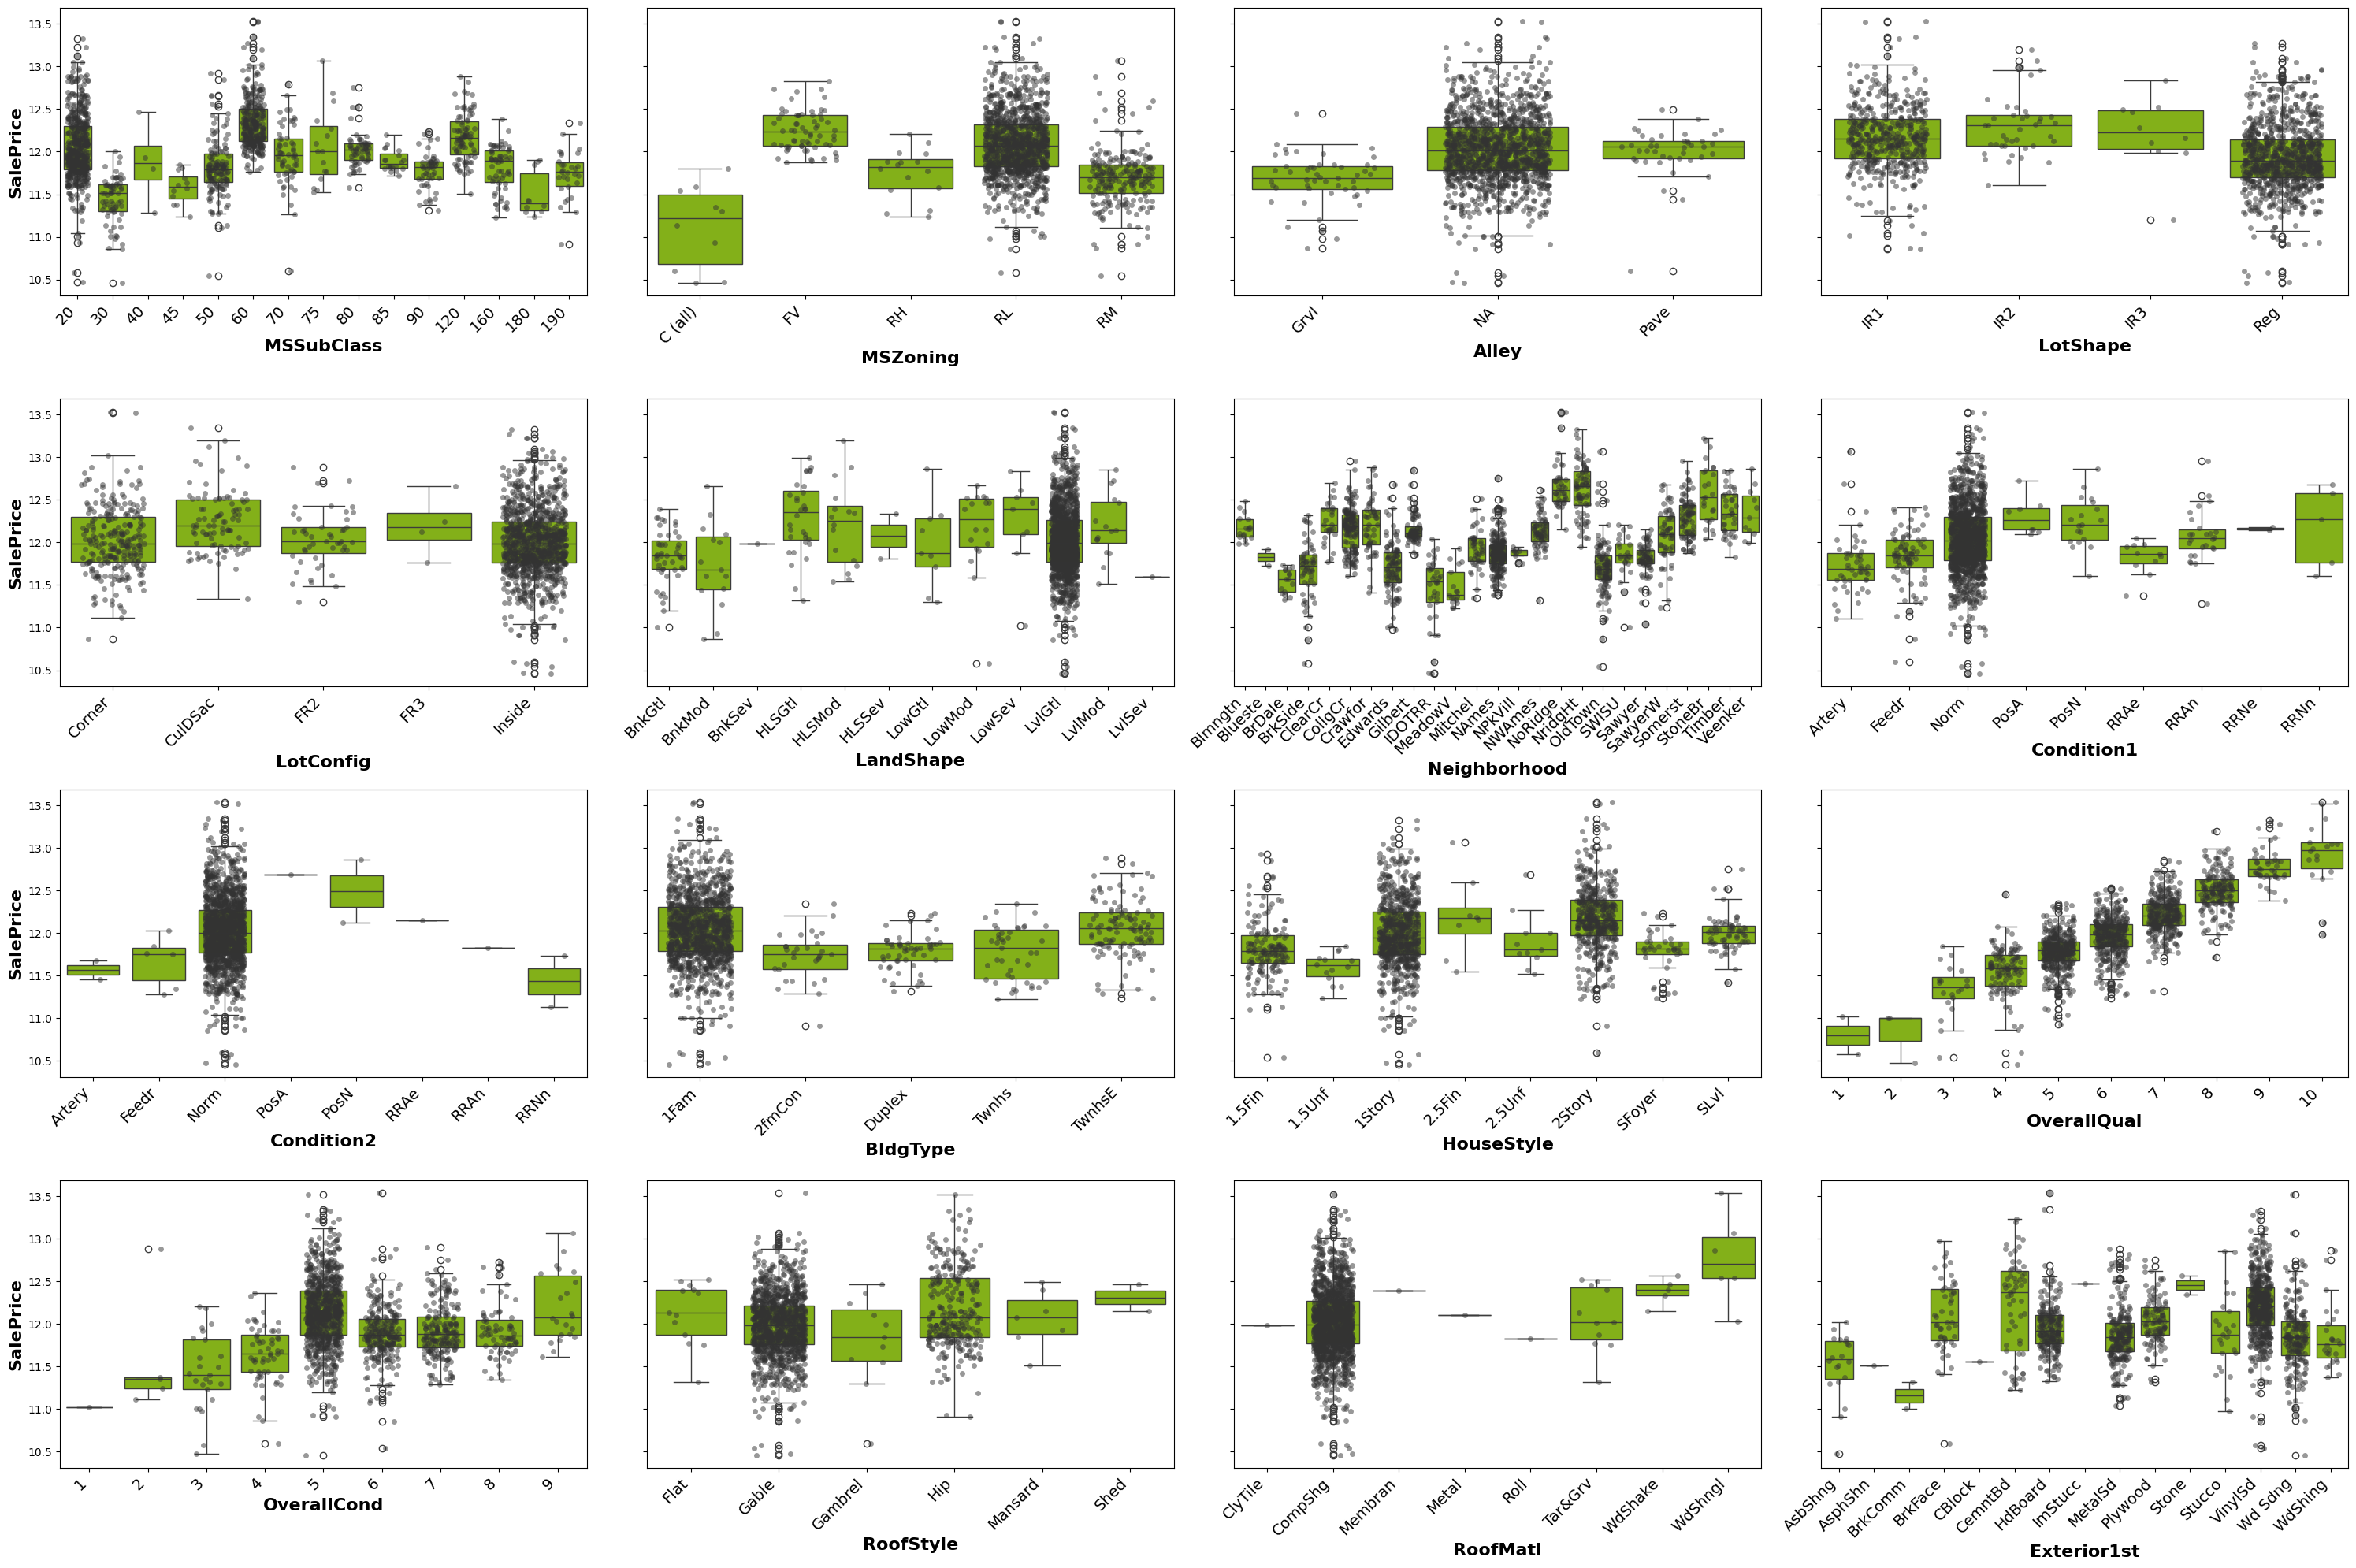

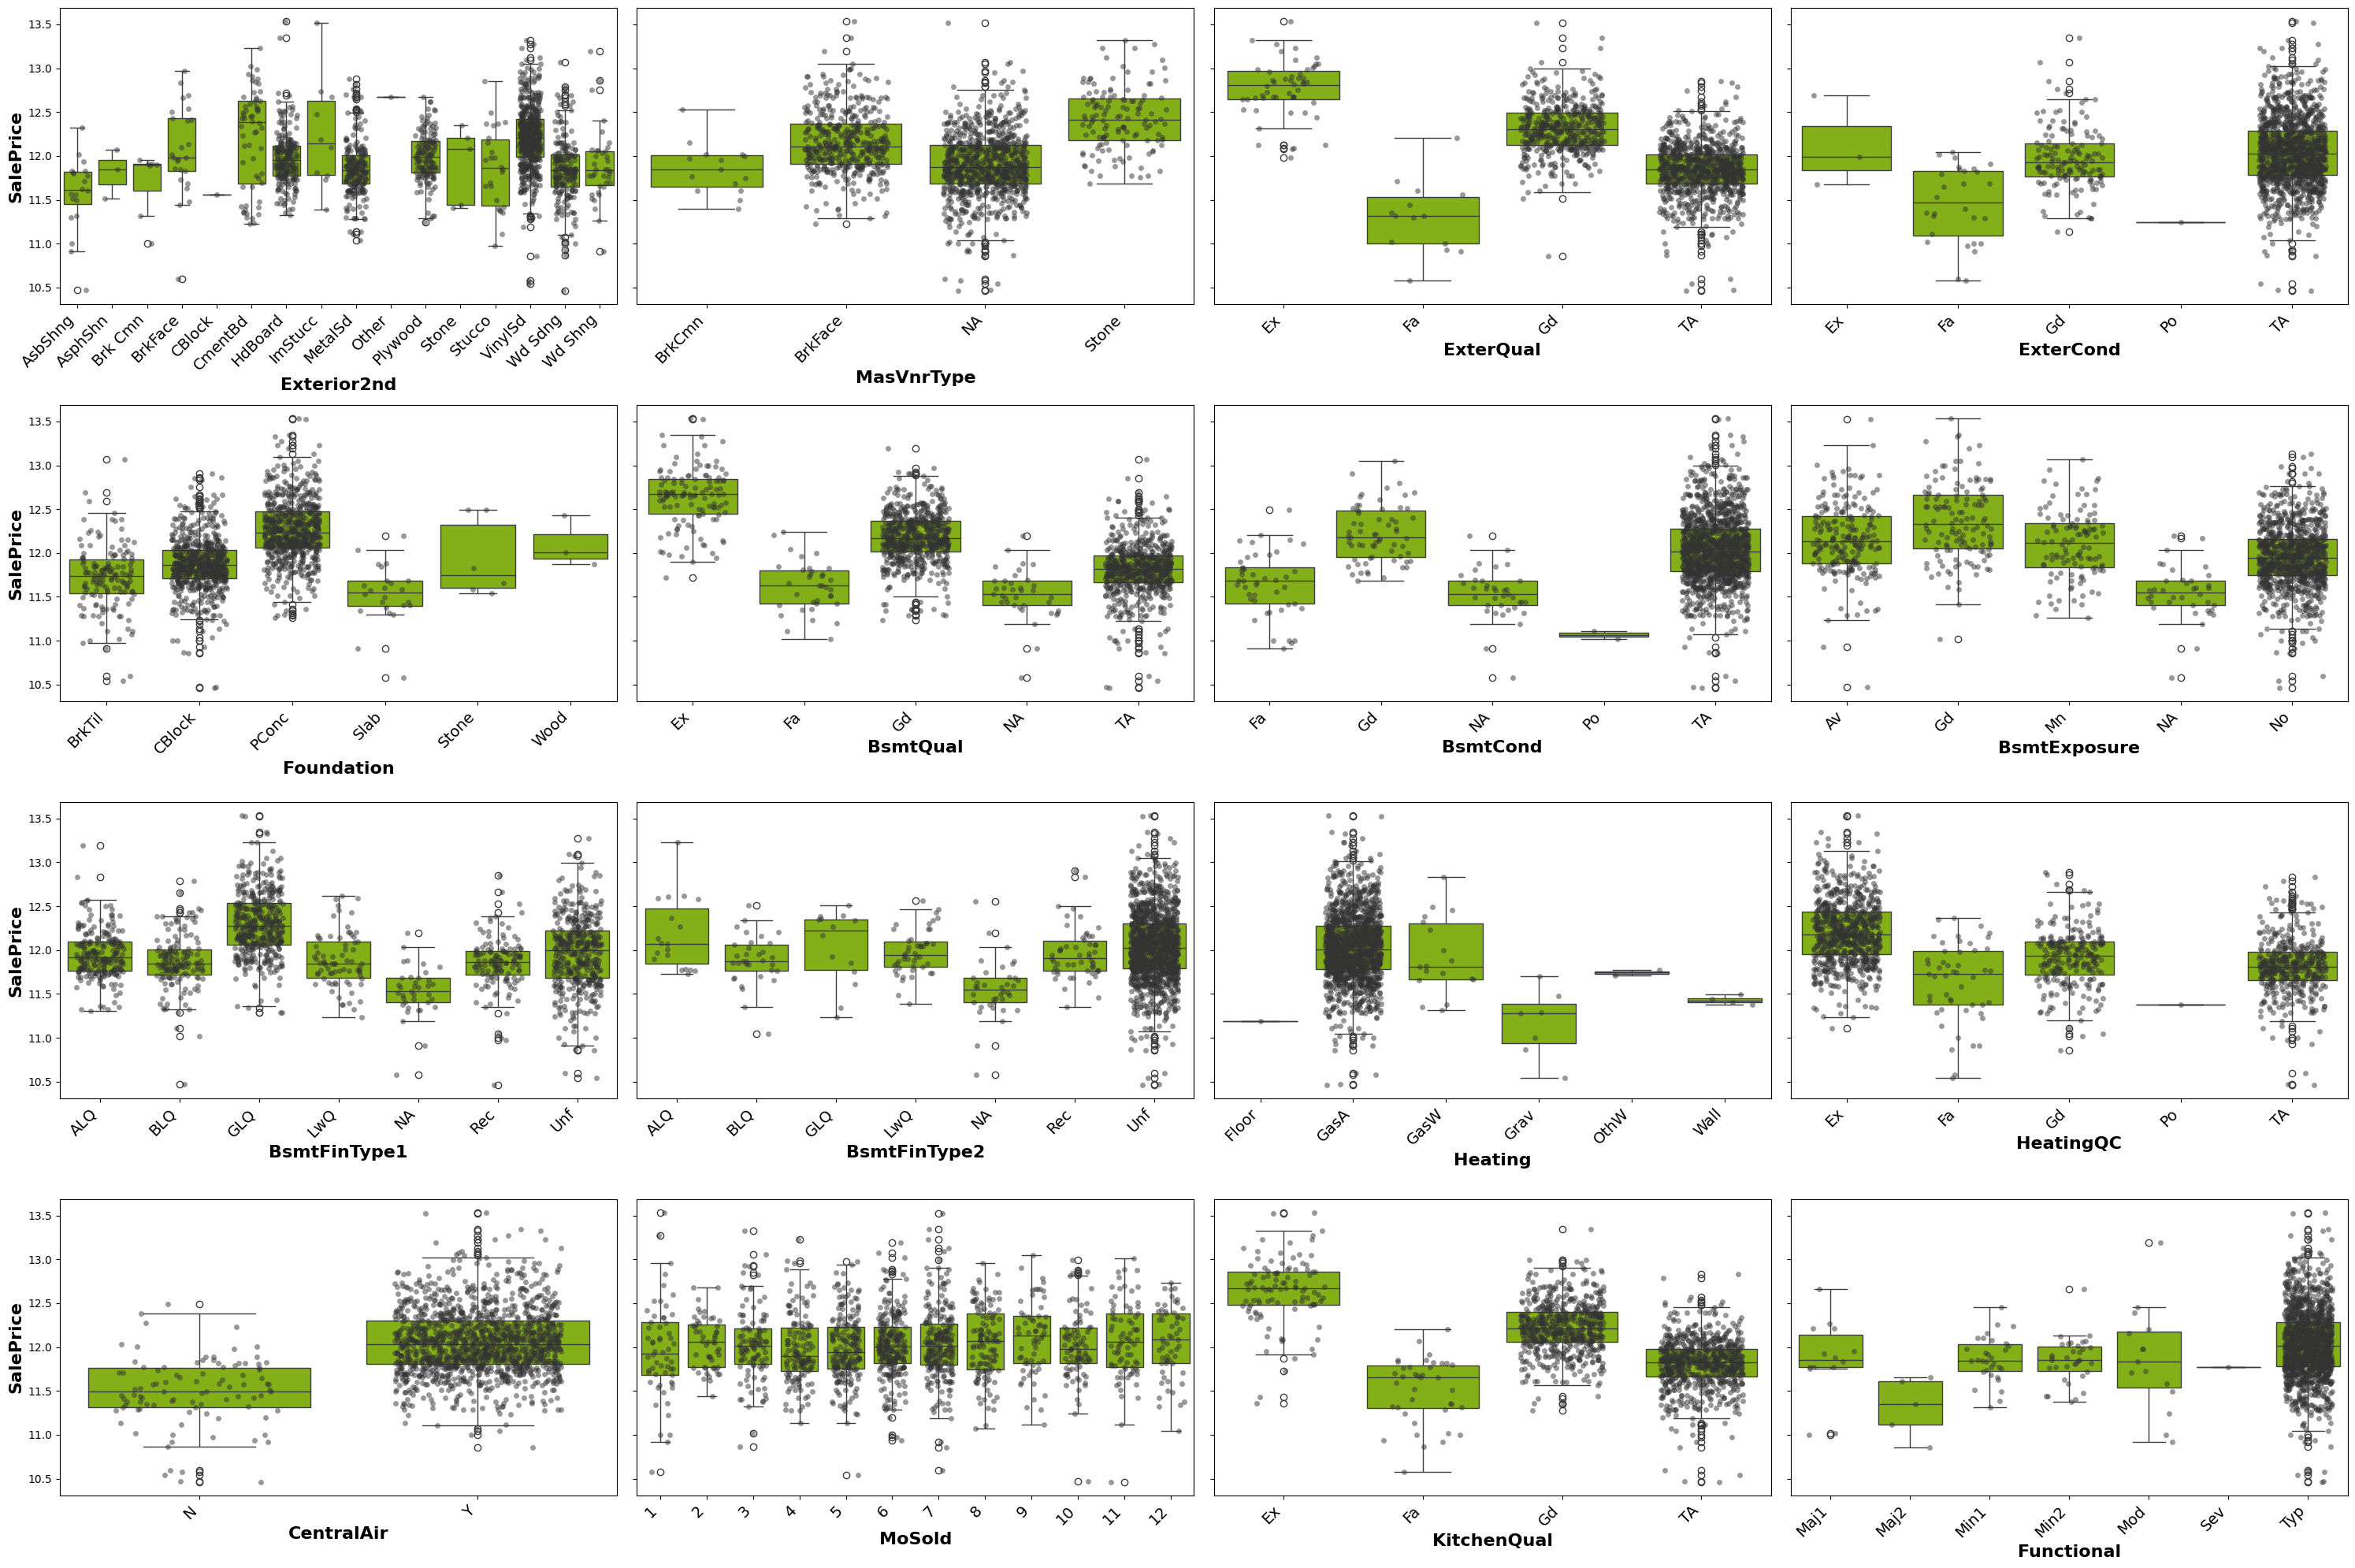

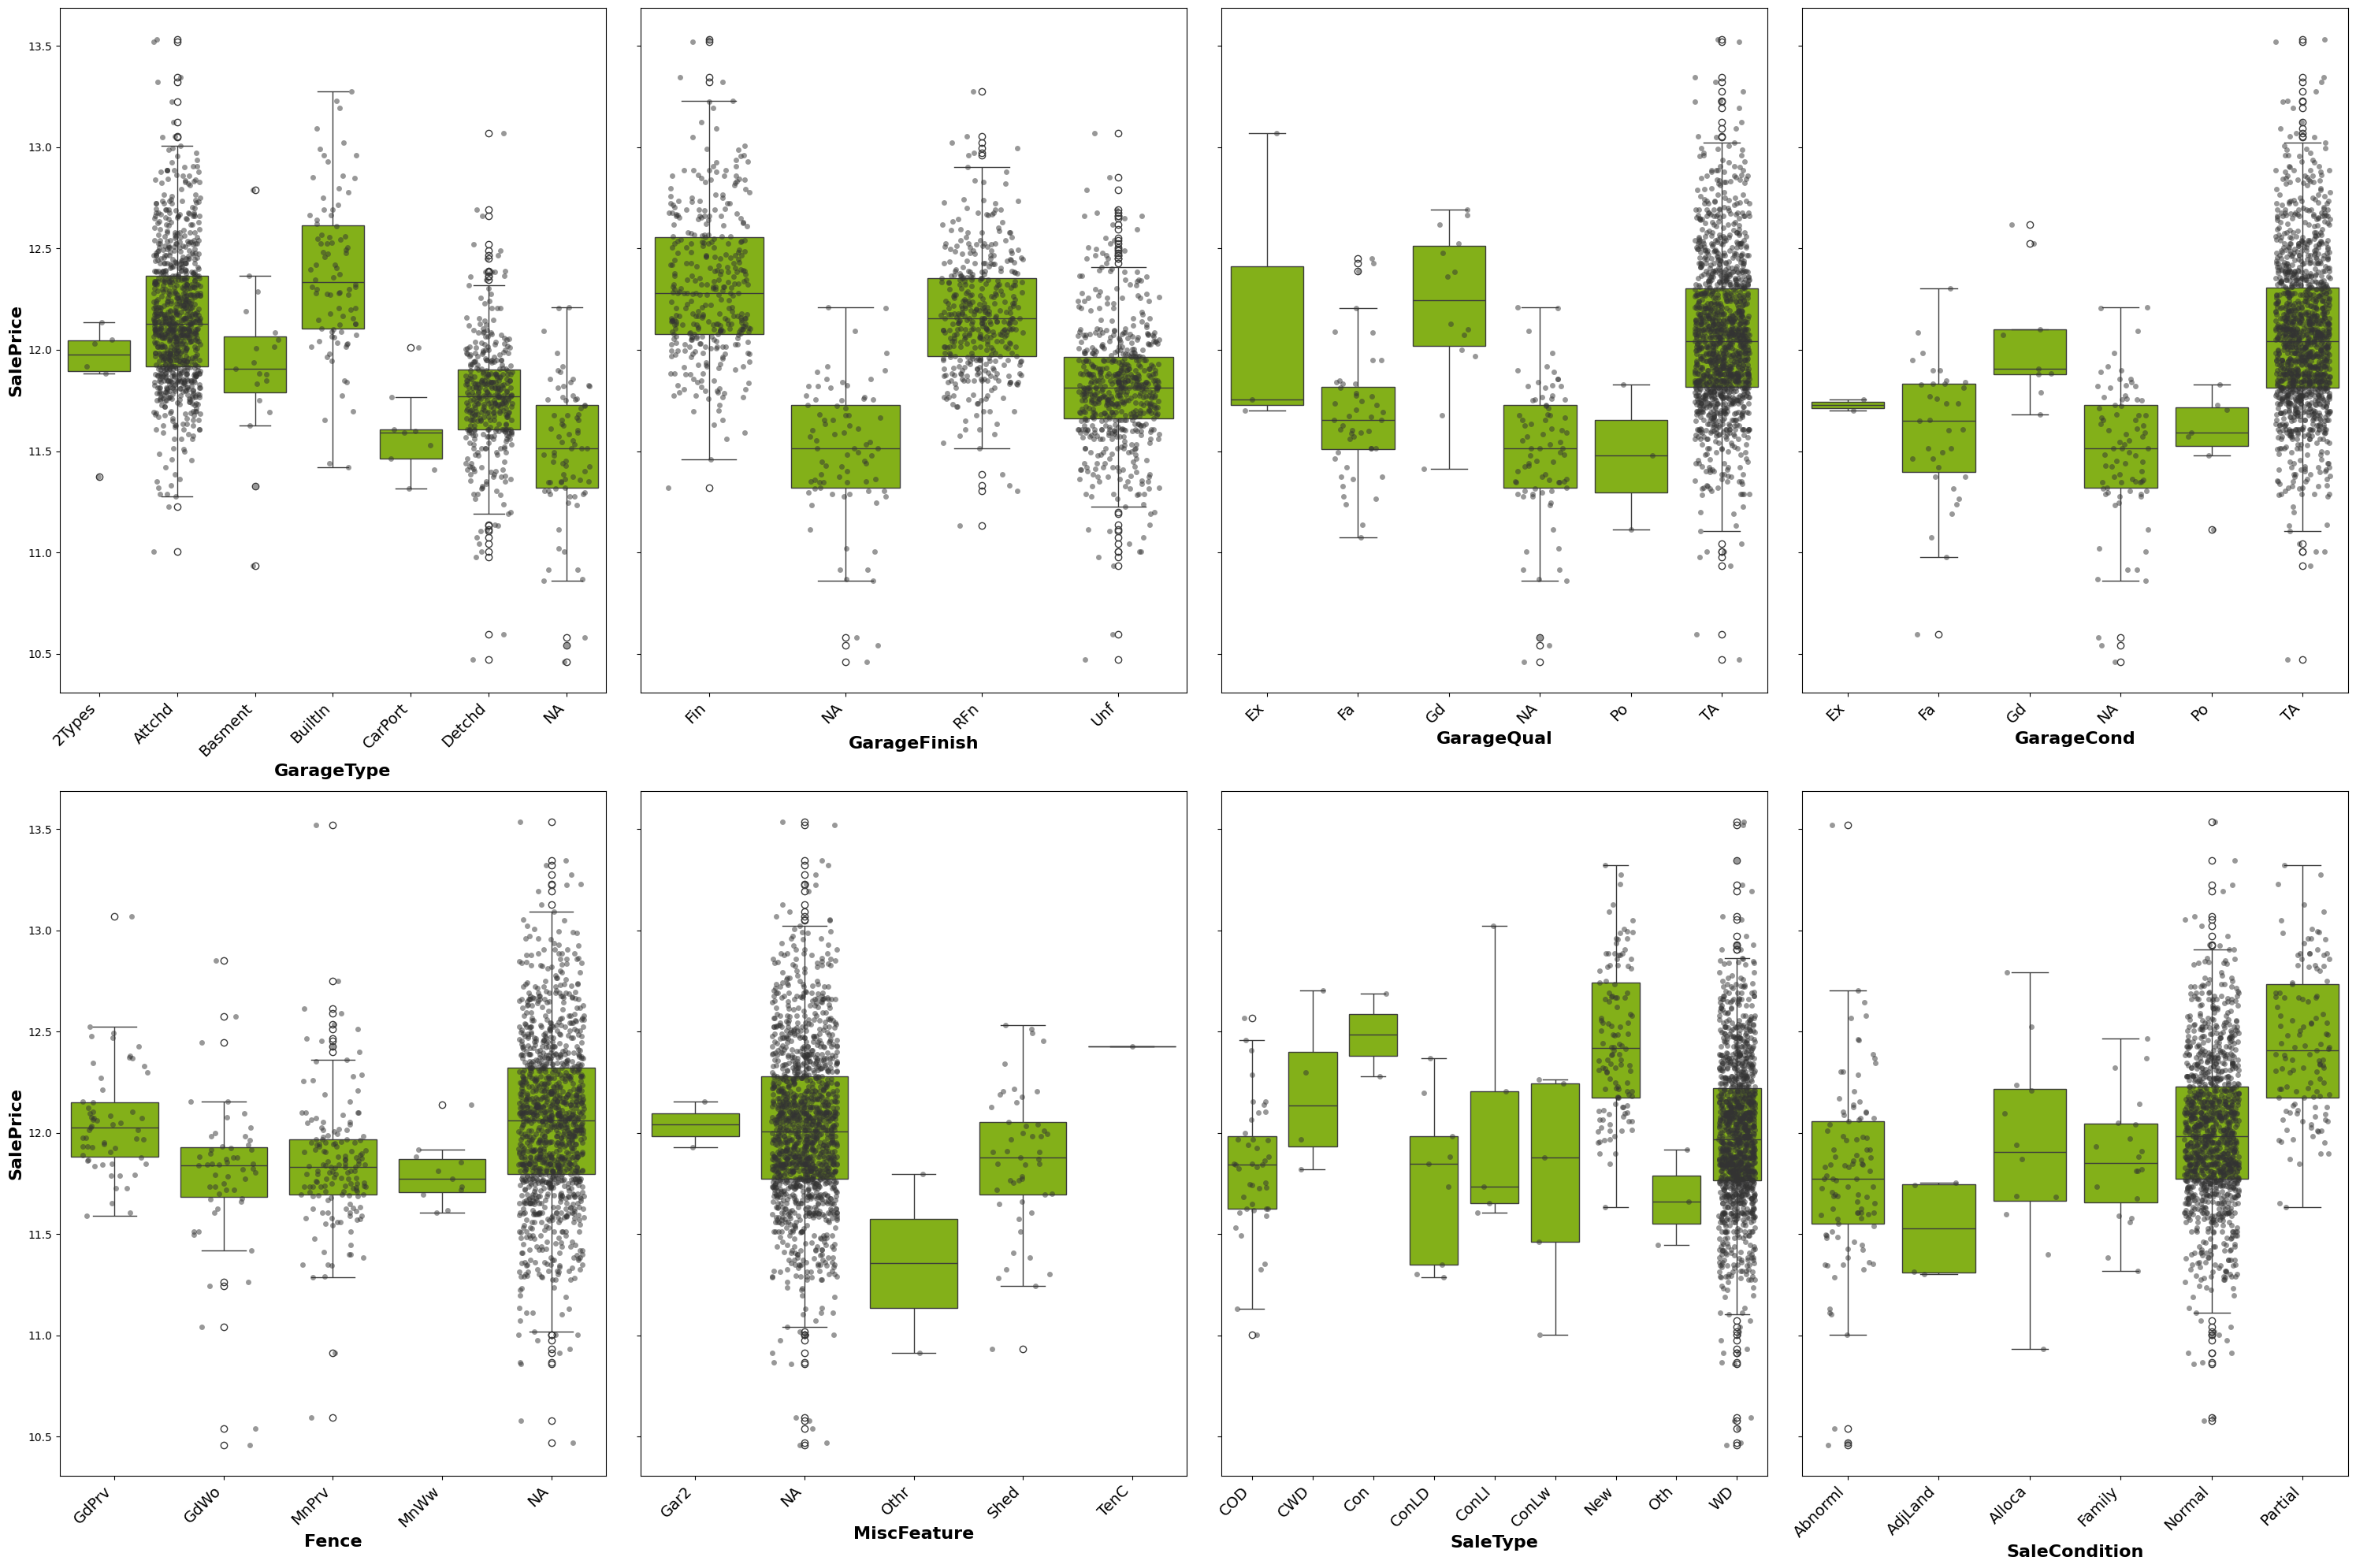

In [13]:
fig_0, axes_0 = plt.subplots(4, 4, figsize=(30, 20), sharey=True, layout='tight')
axes_0f = axes_0.flatten()

for _i, _f in enumerate(cat_features_1):
    _cat_order = sorted(train_pp[_f].unique().tolist())
    sns.boxplot(data=train_pp, x=_f, y='SalePrice', color='#8dc900', order=_cat_order, ax=axes_0f[_i])
    sns.stripplot(data=train_pp, x=_f, y='SalePrice', color='#333333', alpha=0.5, order=_cat_order, jitter=0.3, dodge=True, ax=axes_0f[_i])
    # rotate x-axis labels for better readability
    # axes_f[_i].tick_params(axis='x', rotation=45, labelsize=14)
    # align x tick labels to the left
    axes_0f[_i].set_xticks(range(len(_cat_order)))
    axes_0f[_i].set_xticklabels(_cat_order, ha='right', rotation=45, fontsize=14)

    axes_0f[_i].set_xlabel(_f, fontsize=16, fontweight='bold')

for i in range(4):
    axes_0[i, 0].set_ylabel('SalePrice', fontsize=16, fontweight='bold')

plt.show()

fig_1, axes_1 = plt.subplots(4, 4, figsize=(30, 20), sharey=True, layout='tight')
axes_1f = axes_1.flatten()

for _i, _f in enumerate(cat_features_2):
    try:
        _cat_order = sorted(train_pp[_f].unique().tolist())
    except TypeError:
        print(_f)
        print(train_pp[_f].unique().tolist())
    sns.boxplot(data=train_pp, x=_f, y='SalePrice', color='#8dc900', order=_cat_order, ax=axes_1f[_i])
    sns.stripplot(data=train_pp, x=_f, y='SalePrice', color='#333333', alpha=0.5, order=_cat_order, jitter=0.3, dodge=True, ax=axes_1f[_i])
    # rotate x-axis labels for better readability
    # axes_f[_i].tick_params(axis='x', rotation=45, labelsize=14)
    # align x tick labels to the left
    axes_1f[_i].set_xticks(range(len(_cat_order)))
    axes_1f[_i].set_xticklabels(_cat_order, ha='right', rotation=45, fontsize=14)

    axes_1f[_i].set_xlabel(_f, fontsize=16, fontweight='bold')

for i in range(4):
    axes_1[i, 0].set_ylabel('SalePrice', fontsize=16, fontweight='bold')

plt.show()

fig_2, axes_2 = plt.subplots(2, 4, figsize=(30, 20), sharey=True, layout='tight')
axes_2f = axes_2.flatten()

for _i, _f in enumerate(cat_features_3):
    try:
        _cat_order = sorted(train_pp[_f].unique().tolist())
    except TypeError:
        print(_f)
        print(train_pp[_f].unique().tolist())
    sns.boxplot(data=train_pp, x=_f, y='SalePrice', color='#8dc900', order=_cat_order, ax=axes_2f[_i])
    sns.stripplot(data=train_pp, x=_f, y='SalePrice', color='#333333', alpha=0.5, order=_cat_order, jitter=0.3, dodge=True, ax=axes_2f[_i])
    # rotate x-axis labels for better readability
    # axes_f[_i].tick_params(axis='x', rotation=45, labelsize=14)
    # align x tick labels to the left
    axes_2f[_i].set_xticks(range(len(_cat_order)))
    axes_2f[_i].set_xticklabels(_cat_order, ha='right', rotation=45, fontsize=14)

    axes_2f[_i].set_xlabel(_f, fontsize=16, fontweight='bold')

for i in range(2):
    axes_2[i, 0].set_ylabel('SalePrice', fontsize=16, fontweight='bold')

plt.show()

# Training and validation

In [41]:
dtypes_dict = {
    'num': [
        'LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 
        'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 
        'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 
        'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 
        'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 
        'Fireplaces', 'GarageYrBuilt', 'GarageArea', 'WoodDeckSF', 
        'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 
        'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 
        'Age', 'YrsSinceRemodel', 'RemodelAgeInteraction', 'RoomsPerSqft',
        'BathsPerBedrooms', 'SqftPerRoom', 'QualXSize'
        ],
    'cat_te': [
        'MSSubClass', 'MSZoning', 'Alley', 'LotShape', 
        'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 
        'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond',
        'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 
        'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 
        'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
        'BsmtFinType2', 'Heating', 'HeatingQC', 'Electrical', 
        'CentralAir', 'KitchenQual', 'Functional', 'GarageType', 
        'GarageFinish', 'GarageQual', 'GarageCond', 'Fence',
        'SaleType', 'SaleCondition', 'LandShape', 'WasRemodeled'
        ],
    'cat_ohe': ['MiscFeature']
}

In [42]:
models = {
    'XGBoost': XGBRegressor(
        n_estimators=600, 
        max_depth=5, 
        learning_rate=0.01, 
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
        ),
    'LightGBM': LGBMRegressor(
        n_estimators=600, 
        max_depth=6, 
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1),
    'CatBoost': CatBoostRegressor(
        iterations=600, 
        depth=6, 
        learning_rate=0.01, 
        verbose=0
        )
}

In [ ]:
train.dropna(subset='Electrical', inplace=True)
X_train = train.drop(columns=['SalePrice'])
y_train = train['SalePrice']
X_train_pp = preprocess_data(X_train)

# Debugging check that there is no NAs in each column:
require_imputing = []
for col in X_train_pp.columns:
    if X_train_pp[col].isna().sum() > 0:
        require_imputing.append(col)
        print(f"Column {col} has {X_train_pp[col].isna().sum()} NAs")

Column LotFrontage has 259 NAs
Column MasVnrArea has 8 NAs


In [44]:
print(X_train_pp.shape, y_train.shape)

(1459, 81) (1459,)


In [ ]:
from sklearn.preprocessing import SplineTransformer


kf = KFold(n_splits=10, random_state=42, shuffle=True)

cv_scores = {model_name: [] for model_name in models.keys()}

for model_name, model in models.items():
    print(f"Started CV for model: {model_name}")
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_pp, y_train)):

        # ===== SPLIT DATA INTO TRAIN AND VALIDATION FOLDS =====
        X_train_fold = X_train_pp.iloc[train_idx].copy()
        y_train_fold = y_train.iloc[train_idx].copy()
        X_val_fold = X_train_pp.iloc[val_idx].copy()
        y_val_fold = y_train.iloc[val_idx].copy()

        print(f"Train fold: X={X_train_fold.shape}, Val fold: X={X_val_fold.shape}")

        target_encoder = TargetEncoder(
            target_type='continuous',
            smooth=10,
            cv=5,
            shuffle=True,
            random_state=42
        )
        target_encoder.fit(X_train_fold[dtypes_dict['cat_te']], y_train_fold)
        print(f"  Encoded shape: {target_encoder.transform(X_train_fold[dtypes_dict['cat_te']]).shape}")

        # TRANSFORM both folds using the fold-trained encoder
        X_train_te = X_train_fold.copy()
        X_train_te[dtypes_dict['cat_te']] = pd.DataFrame(
            target_encoder.transform(X_train_fold[dtypes_dict['cat_te']]),
            columns=dtypes_dict['cat_te'],
            index=X_train_fold.index
        )

        X_val_te = X_val_fold.copy()
        X_val_te[dtypes_dict['cat_te']] = pd.DataFrame(
            target_encoder.transform(X_val_fold[dtypes_dict['cat_te']]),
            columns=dtypes_dict['cat_te'],
            index=X_val_fold.index
        )

        preprocessor = ColumnTransformer(
            transformers=[
                ('onehot', 
                OneHotEncoder(
                    drop='first', 
                    sparse_output=False, 
                    handle_unknown='ignore'
                ), 
                dtypes_dict['cat_ohe']),
                ('rbf',
                #  RepeatingBasisFunction(
                #      n_periods=4,
                #      column="MoSold",
                #      input_range=(1, 12),
                #      remainder="passthrough"
                #  ),
                #  ['MoSold']),
                SplineTransformer(
                    extrapolation='periodic',
                    degree=3, 
                    n_knots=4, 
                    include_bias=False
                ), 
                ['MoSold'])
            ],
            remainder='passthrough',
            verbose_feature_names_out=False
        )

        preprocessor.fit(X_train_te)

        X_train_ct = preprocessor.transform(X_train_te)
        X_val_ct = preprocessor.transform(X_val_te)

        feature_names = preprocessor.get_feature_names_out()
        X_train_ct_df = pd.DataFrame(X_train_ct, columns=feature_names, index=X_train_fold.index)
        X_val_ct_df = pd.DataFrame(X_val_ct, columns=feature_names, index=X_val_fold.index)

        if require_imputing:

            X_combined = pd.concat([X_train_ct_df, X_val_ct_df], ignore_index=False)

            y_combined = pd.concat([y_train_fold, y_val_fold], ignore_index=False).sort_index()
            X_combined_with_y = X_combined.copy()
            X_combined_with_y['__imputation_target__'] = y_combined

            predictor_cols = [col for col in X_train_ct_df.columns 
                            if X_train_ct_df[col].dtype in ['int64', 'float64'] 
                            and X_train_ct_df[col].isna().sum() == 0]

            for imp_col in require_imputing:
                if imp_col in X_combined_with_y.columns:
                    n_missing = X_combined_with_y[imp_col].isna().sum()
                    if n_missing > 0:
                        X_combined_with_y = regression_imputer(
                            X_combined_with_y,
                            predictor_cols,
                            imp_col,
                            BayesianRidge()
                        )

            # Remove temporary target and split back
            X_combined_imputed = X_combined_with_y.drop(columns=['__imputation_target__'])
            X_train_final = X_combined_imputed.loc[X_train_fold.index].copy()
            X_val_final = X_combined_imputed.loc[X_val_fold.index].copy()

        else:
            X_train_final = X_train_ct_df.copy()
            X_val_final = X_val_ct_df.copy()
        
        X_train_final.drop(columns=['Id'], inplace=True)
        X_val_final.drop(columns=['Id'], inplace=True)


        model.fit(X_train_final, y_train_fold)
        y_pred = model.predict(X_val_final)
        score = rmse_log(y_val_fold, y_pred)
        cv_scores[model_name].append(score)

        print(f"  Train shape: {X_train_final.shape}")
        print(f"  Val shape: {X_val_final.shape}")
        print(f"  RMSE_log: {score:.4f}")


    print(f"CV summary for model: {model_name}")
    print(f"Fold RMSE_log scores: {[f'{s:.4f}' for s in cv_scores[model_name]]}")
    print(f"Mean RMSE_log: {np.mean(cv_scores[model_name]):.4f} (+/- {np.std(cv_scores[model_name]):.4f})")
    print(f"Min: {np.min(cv_scores[model_name]):.4f}, Max: {np.max(cv_scores[model_name]):.4f}")

In [51]:
for model_name, scores in cv_scores.items():
    print(f"{model_name}: Mean RMSE_log = {np.mean(scores):.4f} (+/- {np.std(scores):.4f}), Min = {np.min(scores):.4f}, Max = {np.max(scores):.4f}")

XGBoost: Mean RMSE_log = 0.1335 (+/- 0.0249), Min = 0.0910, Max = 0.1904
LightGBM: Mean RMSE_log = 0.1361 (+/- 0.0222), Min = 0.0950, Max = 0.1808
CatBoost: Mean RMSE_log = 0.1380 (+/- 0.0234), Min = 0.0975, Max = 0.1798
